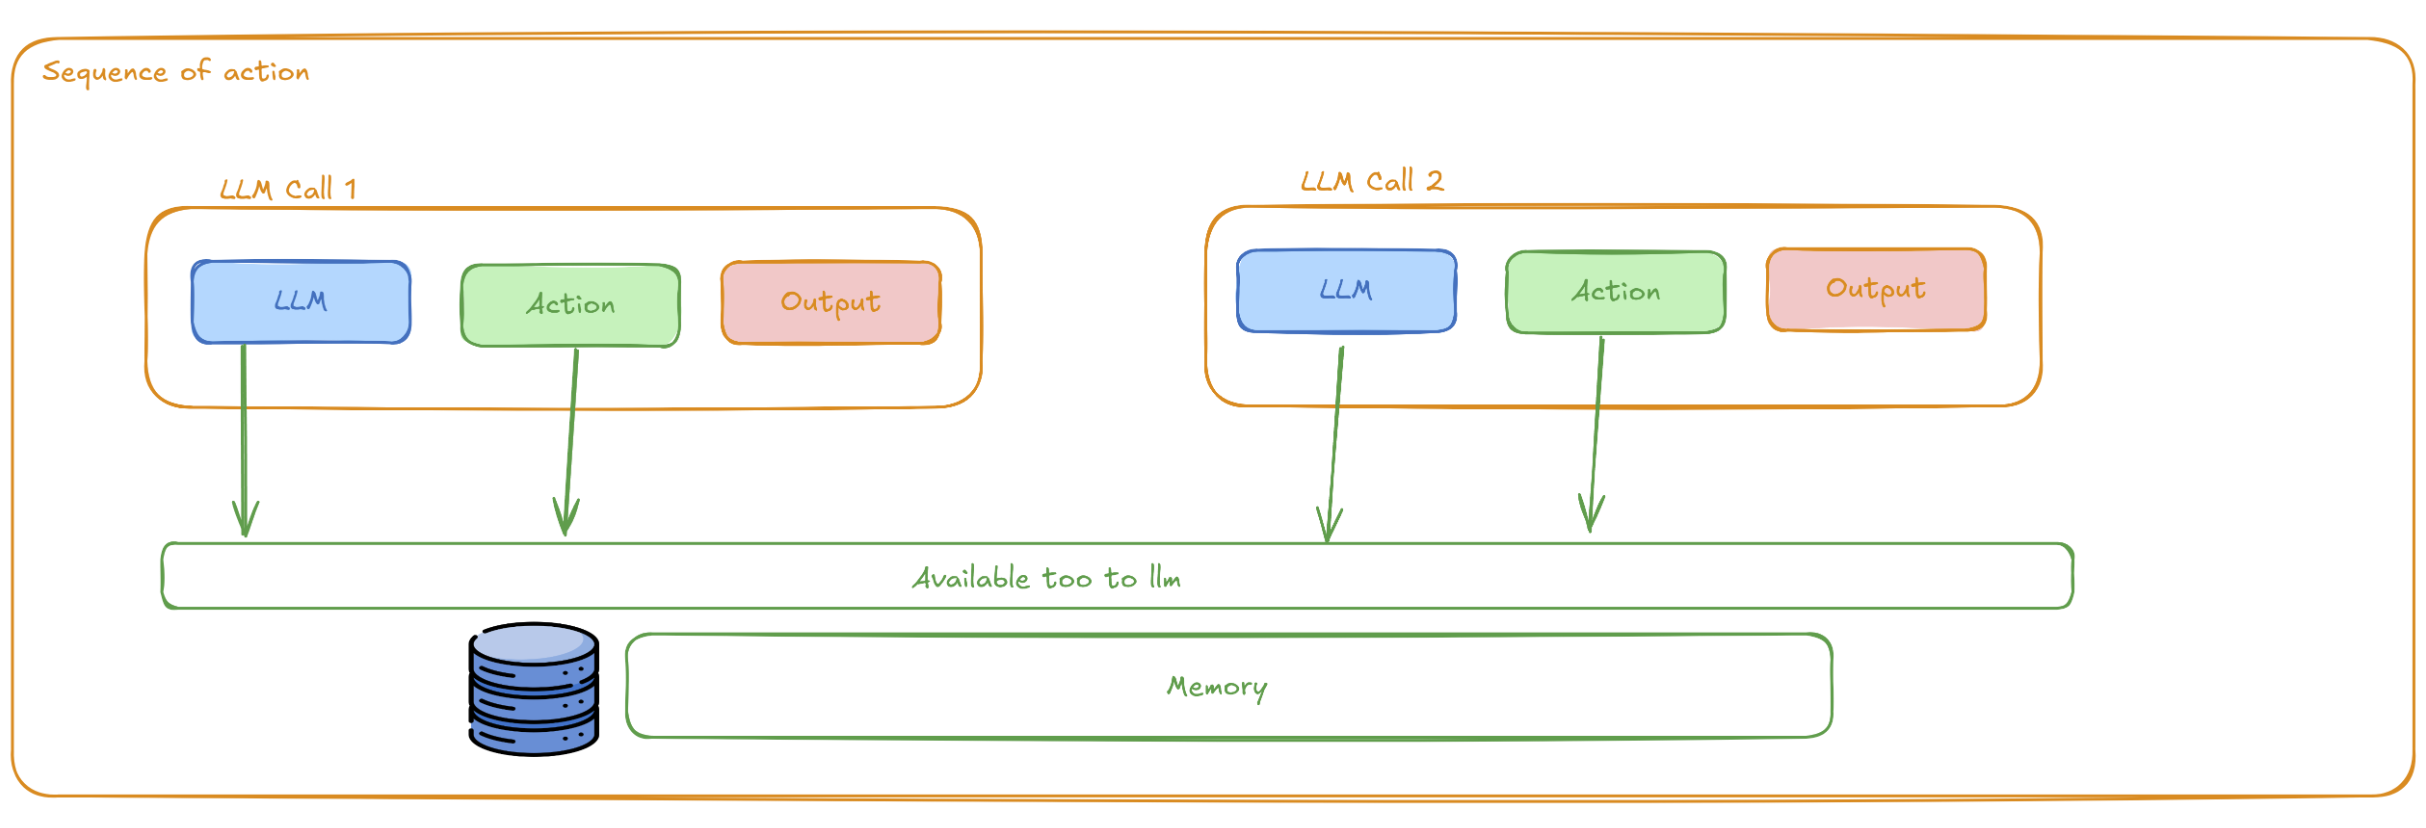


In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END

from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import ToolNode

# store conversation in memory checkpoints. It uses RAM by default
from langgraph.checkpoint.memory import MemorySaver

# Configuration
BASE_URL = "http://localhost:11434"
MODEL_NAME = "qwen3"

llm = ChatOllama(model=MODEL_NAME, base_url=BASE_URL)

In [3]:
import humra_tools

humra_tools.calculate.invoke({"expression": "6*8"})

all_tools = [humra_tools.calculate, humra_tools.get_weather]

[TOOL] calculate ('6*8') -> '48'


In [4]:
# Create Agent State
class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

In [5]:
## Agent Node
def agent_node(state: AgentState):
    llm_with_tools = llm.bind_tools(all_tools)
    
    system_message = SystemMessage("""You are a friendly assistant with memory. 
                                   Use the availale tools to help the user when needed.
                                   
                                   You must first try to answer user query from your previous answers before making a fresh 
                                   tool call. Do not make answers by yourself if you are not sure.""")
    
    messages = [system_message] + state['messages']
    # print(f"[AGENT] Received messages: {messages}")
    
    response = llm_with_tools.invoke(messages)
    
    if hasattr(response, 'tool_calls') and response.tool_calls:
        for tc in response.tool_calls:
            print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
    else:
        print("[AGENT] Responding...")
        
    return {"messages": [response]}

In [6]:
state = {"messages": [HumanMessage("Hi")]}
result = agent_node(state)
result

[AGENT] Responding...


{'messages': [AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-03-13T03:24:07.089782Z', 'done': True, 'done_reason': 'stop', 'total_duration': 12944635458, 'load_duration': 2379575208, 'prompt_eval_count': 475, 'prompt_eval_duration': 4901355500, 'eval_count': 61, 'eval_duration': 5281359876, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019ce538-d99b-7870-8dc2-ac305c967671-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 475, 'output_tokens': 61, 'total_tokens': 536})]}

In [7]:
# Routing
def should_continue(state: AgentState):
    last = state['messages'][-1]
    
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return "tools"
    else:
        return END

In [8]:
# =============================================================================
# Graph
# =============================================================================
def create_agent():

    builder = StateGraph(AgentState)

    builder.add_node("agent", agent_node)
    builder.add_node("tools", ToolNode(all_tools), message_key="messages")


    builder.add_edge(START, "agent")
    builder.add_conditional_edges("agent", should_continue, ["tools", END])

    builder.add_edge("tools", "agent")

    # add checkpoint for memory across the sessions
    checkpointer = MemorySaver()

    graph = builder.compile(checkpointer=checkpointer)

    return graph

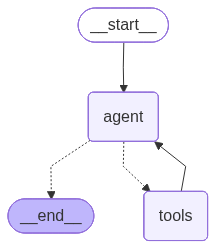

In [9]:
agent = create_agent()
agent

In [10]:
config = {"configurable": {"thread_id": "sabbha"}}


query = "What is the current weather in Kolkata?"
result = agent.invoke({'messages': [HumanMessage(query)]}, config=config)
result

[AGENT] called Tool get_weather with args {'location': 'Kolkata'}
[TOOL] get_weather ('location') -> 'Kolkata'
[AGENT] Responding...


{'messages': [HumanMessage(content='What is the current weather in Kolkata?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-03-13T03:24:18.389535Z', 'done': True, 'done_reason': 'stop', 'total_duration': 10461348000, 'load_duration': 100270917, 'prompt_eval_count': 482, 'prompt_eval_duration': 311651083, 'eval_count': 110, 'eval_duration': 9573641753, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019ce539-0f76-74d1-a380-21eda61c34eb-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Kolkata'}, 'id': '54a5ccf0-7d8e-415c-900d-39fbb98042f5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 482, 'output_tokens': 110, 'total_tokens': 592}),
  ToolMessage(content='{"location": {"name": "Kolkata", "region": "West Bengal", "country": "India", "lat": 22.5697, "lon": 88.3697, "tz_id": "Asia/Kolkata", "localtime_epoch": 1

In [11]:
query = "What is 2+32 and 5-7"
result = agent.invoke({'messages': [HumanMessage(query)]}, config=config)
result

[AGENT] called Tool calculate with args {'expression': '2 + 32'}
[AGENT] called Tool calculate with args {'expression': '5 - 7'}
[TOOL] calculate ('2 + 32') -> '34'
[TOOL] calculate ('5 - 7') -> '-2'
[AGENT] Responding...


{'messages': [HumanMessage(content='What is the current weather in Kolkata?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-03-13T03:24:18.389535Z', 'done': True, 'done_reason': 'stop', 'total_duration': 10461348000, 'load_duration': 100270917, 'prompt_eval_count': 482, 'prompt_eval_duration': 311651083, 'eval_count': 110, 'eval_duration': 9573641753, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019ce539-0f76-74d1-a380-21eda61c34eb-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Kolkata'}, 'id': '54a5ccf0-7d8e-415c-900d-39fbb98042f5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 482, 'output_tokens': 110, 'total_tokens': 592}),
  ToolMessage(content='{"location": {"name": "Kolkata", "region": "West Bengal", "country": "India", "lat": 22.5697, "lon": 88.3697, "tz_id": "Asia/Kolkata", "localtime_epoch": 1

##### Stream Agent Output


In [13]:
def chat(query, thread_id):

    config = {"configurable": {"thread_id": thread_id}}

    for chunk in agent.stream({'messages': [query]}, config=config):

        if 'agent' in chunk:
            chunk = chunk.get('agent')
        else:
            chunk = chunk.get('tools')

        if hasattr(chunk, 'tool_calls') and chunk.tool_calls:
            for tc in chunk.tool_calls:
                print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
        else:
            print(f"[AGENT/ToolMessage] Responding.\n{chunk['messages'][0].content}")

        # print(chunk)        


query = "What is the current weather in Mumbai?"
chat(query, "ssm")

[AGENT] called Tool get_weather with args {'location': 'Mumbai'}
[AGENT/ToolMessage] Responding.

[TOOL] get_weather ('location') -> 'Mumbai'
[AGENT/ToolMessage] Responding.
{"location": {"name": "Mumbai", "region": "Maharashtra", "country": "India", "lat": 18.975, "lon": 72.826, "tz_id": "Asia/Kolkata", "localtime_epoch": 1773372434, "localtime": "2026-03-13 08:57"}, "current": {"last_updated_epoch": 1773371700, "last_updated": "2026-03-13 08:45", "temp_c": 29.3, "temp_f": 84.7, "is_day": 1, "condition": {"text": "Mist", "icon": "//cdn.weatherapi.com/weather/64x64/day/143.png", "code": 1030}, "wind_mph": 5.6, "wind_kph": 9.0, "wind_degree": 23, "wind_dir": "NNE", "pressure_mb": 1010.0, "pressure_in": 29.83, "precip_mm": 0.0, "precip_in": 0.0, "humidity": 70, "cloud": 0, "feelslike_c": 31.5, "feelslike_f": 88.6, "windchill_c": 27.6, "windchill_f": 81.7, "heatindex_c": 28.9, "heatindex_f": 84.1, "dewpoint_c": 18.5, "dewpoint_f": 65.2, "vis_km": 1.2, "vis_miles": 0.0, "uv": 1.3, "gust_mp

In [14]:
query = "hi, my name is sabbha."
chat(query, "sabbha")

[AGENT] Responding...
[AGENT/ToolMessage] Responding.
Hello, Sabbha! 👋 I'm Qwen, your friendly assistant. How can I help you today? 😊


In [15]:
query = "hi, what is my name?"
chat(query, "sabbha")

[AGENT] Responding...
[AGENT/ToolMessage] Responding.
Your name is **Sabbha**! 😊 How can I assist you today?


In [16]:
query = "hi, what is my name?"
chat(query, "ssm")

[AGENT] Responding...
[AGENT/ToolMessage] Responding.
I don't have access to your name unless you've shared it in our conversation history. Since we've never met before, could you please tell me your name? I'd love to address you properly! 😊


In [17]:
query = "Hi, can you summarize my previous messages. don't make a tool call."
chat(query, "sabbha")

[AGENT] Responding...
[AGENT/ToolMessage] Responding.
Here’s a summary of your previous messages:

1. **Weather Inquiry**: You asked for the current weather in Kolkata.  
2. **Math Calculations**: You requested the results of `2 + 32` and `5 - 7`.  
3. **Name Confirmation**: You introduced yourself as "Sabbha" and later asked for your name.  
4. **Summary Request**: You now asked for a summary of your previous messages.  

Let me know if you need further assistance! 😊
